In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(505)
n = 300
cols = ['temperature', 'occupancy', 'runtime', 'load']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.4, 0.8, 0.7, 1.1])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["high_demand"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_e.csv", index=False)

In [4]:
df.head()

,record_id,temperature,occupancy,runtime,load,group,high_demand
0,1,62.72,37.48,54.22,33.72,G2,0
1,2,47.61,48.01,56.53,43.47,G1,0
2,3,56.75,40.57,43.42,38.98,G1,0
3,4,68.37,24.76,56.64,32.77,G2,0
4,5,50.42,NaN,60.99,57.30,G1,1


### Task 1 — Maths & Adv Stats

M1 - Descriptive Statistics 

In [6]:
df.describe()

,record_id,temperature,occupancy,runtime,load,high_demand
count,305.000000,290.000000,289.000000,305.000000,305.000000,305.000000
mean,148.081967,50.690828,49.533633,50.506426,49.838820,0.560656
std,88.052447,10.224950,9.812647,10.113146,9.955211,0.497123
min,1.000000,24.870000,18.020000,22.890000,23.290000,0.000000
25%,72.000000,43.217500,43.170000,43.700000,43.160000,0.000000
50%,148.000000,50.525000,49.280000,50.900000,50.050000,1.000000
75%,224.000000,58.190000,56.240000,57.200000,56.890000,1.000000
max,300.000000,84.850000,76.520000,83.480000,80.110000,1.000000


Text(0.5, 1.0, 'Histogram of Temperature')

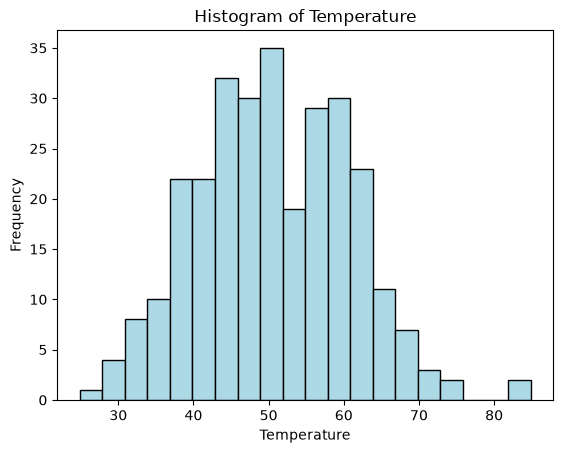

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["temperature"],bins=20,color="lightblue", edgecolor="black")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.title("Histogram of Temperature")

M2 — Statistical Inference

In [15]:
G1=df.groupby('group')['load'].mean()
print('Mean load between G1 and G2:')
G1

Mean load between G1 and G2:


group
G1    49.603816
G2    50.072288
Name: load, dtype: float64

### Task 2 — Data Preprocessing & Feature Engineering

F1 — Audit and Partition

In [29]:
print("Shape: ",df.shape)
print("Duplicates: ",df.duplicated().sum())
print("\nMissing values: \n\n",df.isnull().sum())
print("\nTarget counts: ",'\n',df['high_demand'].value_counts())

Shape:  (305, 7)
Duplicates:  5

Missing values: 

 record_id       0
temperature    15
occupancy      16
runtime         0
load            0
group           0
high_demand     0
dtype: int64

Target counts:  
 high_demand
1    171
0    134
Name: count, dtype: int64


In [40]:
df.drop_duplicates(inplace=True)
df.shape

(300, 7)

F2 — Transform and Engineer

In [46]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df.drop(columns=["record_id", "high_demand"]).copy()
y = df["high_demand"].copy()

X_fit, X_temp, y_fit, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

num_cols = ["temperature", "occupancy", "runtime", "load"]
cat_cols = ["group"]

num_imp = SimpleImputer(strategy="median")
cat_enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

fit_num = num_imp.fit_transform(X_fit[num_cols])
val_num = num_imp.transform(X_val[num_cols])
test_num = num_imp.transform(X_test[num_cols])

fit_cat = cat_enc.fit_transform(X_fit[cat_cols])
val_cat = cat_enc.transform(X_val[cat_cols])
test_cat = cat_enc.transform(X_test[cat_cols])

fit_original = pd.DataFrame(fit_num, columns=num_cols, index=X_fit.index)
val_original = pd.DataFrame(val_num, columns=num_cols, index=X_val.index)
test_original = pd.DataFrame(test_num, columns=num_cols, index=X_test.index)

fit_original["engineered_feature"] = fit_original["load"] / (fit_original["runtime"] + 1)
val_original["engineered_feature"] = val_original["load"] / (val_original["runtime"] + 1)
test_original["engineered_feature"] = test_original["load"] / (test_original["runtime"] + 1)

scale_cols = num_cols + ["engineered_feature"]
scaler = StandardScaler()

fit_scaled = scaler.fit_transform(fit_original[scale_cols])
val_scaled = scaler.transform(val_original[scale_cols])
test_scaled = scaler.transform(test_original[scale_cols])

feature_names = scale_cols + list(cat_enc.get_feature_names_out(cat_cols))

splits = pd.concat([
    X_fit[["record_id"]].assign(partition="fit") if "record_id" in X_fit.columns else pd.DataFrame({"record_id": X_fit.index + 1}).assign(partition="fit"),
    X_val[["record_id"]].assign(partition="validation") if "record_id" in X_val.columns else pd.DataFrame({"record_id": X_val.index + 1}).assign(partition="validation"),
    X_test[["record_id"]].assign(partition="test") if "record_id" in X_test.columns else pd.DataFrame({"record_id": X_test.index + 1}).assign(partition="test")
])

fit_ids = df.loc[X_fit.index, "record_id"]
val_ids = df.loc[X_val.index, "record_id"]
test_ids = df.loc[X_test.index, "record_id"]

pd.DataFrame({
    "record_id": pd.concat([fit_ids, val_ids, test_ids], ignore_index=True),
    "partition": ["fit"] * len(fit_ids) + ["validation"] * len(val_ids) + ["test"] * len(test_ids)
}).to_csv("splits.csv", index=False)

print("fit and validation overlap:", len(set(fit_ids) & set(val_ids)))
print("fit and test overlap:", len(set(fit_ids) & set(test_ids)))

fit and validation overlap: 0
fit and test overlap: 0


In [45]:
X_fit_trans = np.column_stack([fit_scaled, fit_cat])
X_val_trans = np.column_stack([val_scaled, val_cat])
X_test_trans = np.column_stack([test_scaled, test_cat])

print("fit transformed:", X_fit_trans.shape)
print("validation transformed:", X_val_trans.shape)
print("test transformed:", X_test_trans.shape)
print("features:", feature_names)

fit transformed: (180, 7)
validation transformed: (60, 7)
test transformed: (60, 7)
features: ['temperature', 'occupancy', 'runtime', 'load', 'engineered_feature', 'group_G1', 'group_G2']


### Task 3 — Supervised Learning 

S1 — Baseline and Classifier

In [53]:
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

X_fit_model = np.column_stack([fit_scaled, fit_cat])
X_test_model = np.column_stack([test_scaled, test_cat])

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_fit_model, y_fit)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_fit_model, y_fit)

dummy_pred = dummy.predict(X_test_model)
log_pred = log_model.predict(X_test_model)
log_prob = log_model.predict_proba(X_test_model)[:, 1]

def scores(y_true, pred):
    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0)
    }

S2 — Holdout Evaluation

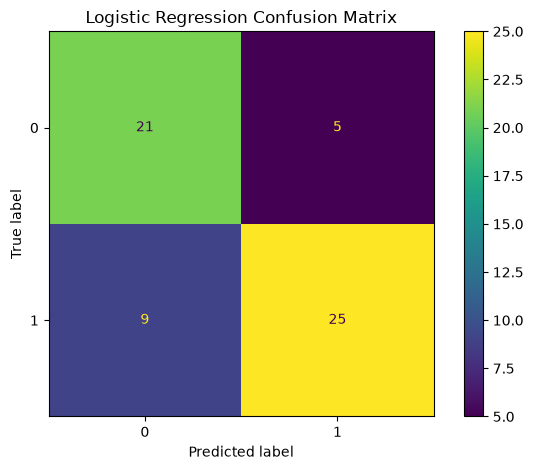

   true_label  predicted_label  class_1_probability
0           0                0             0.127220
1           1                1             0.998157
2           0                0             0.152201
3           0                0             0.002346
4           0                0             0.054994
baseline: {'accuracy': 0.5666666666666667, 'precision': 0.5666666666666667, 'recall': 1.0, 'f1': 0.723404255319149}
logistic: {'accuracy': 0.7666666666666667, 'precision': 0.8333333333333334, 'recall': 0.7352941176470589, 'f1': 0.78125}
Baseline accuracy: 0.5666666666666667
Logistic accuracy: 0.7666666666666667
Logistic F1: 0.78125


In [55]:
cm = confusion_matrix(y_test, log_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig("logistic_confusion_matrix.png")
plt.show()

predictions = pd.DataFrame({
    "true_label": y_test.to_numpy(),
    "predicted_label": log_pred,
    "class_1_probability": log_prob
})
predictions.to_csv("logistic_predictions.csv", index=False)
print(predictions.head())

print("baseline:", scores(y_test, dummy_pred))
print("logistic:", scores(y_test, log_pred))

print("Baseline accuracy:", accuracy_score(y_test, dummy_pred))
print("Logistic accuracy:", accuracy_score(y_test, log_pred))
print("Logistic F1:", f1_score(y_test, log_pred, zero_division=0))

### Task 4 — Unsupervised Learning 
U1 — K-Means and Selection

In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_X = fit_scaled
cluster_results = []

for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(cluster_X)
    inertia = model.inertia_
    silhouette = silhouette_score(cluster_X, labels)
    cluster_results.append([k, inertia, silhouette])
    print("k:", k, "inertia:", inertia, "silhouette:", silhouette)

cluster_scores = pd.DataFrame(cluster_results, columns=["k", "inertia", "silhouette"])
cluster_scores.to_csv("cluster_scores.csv", index=False)

best_k = cluster_scores.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"]
best_k = int(best_k)

kmodel = KMeans(n_clusters=best_k, n_init=10, random_state=42)
cluster_labels = kmodel.fit_predict(cluster_X)

cluster_profile = fit_original.copy()
cluster_profile["cluster"] = cluster_labels

profile = cluster_profile.groupby("cluster")[scale_cols].mean()
print("\nselected k:", best_k)
print('\n',profile)

k: 2 inertia: 671.1329184709773 silhouette: 0.21973945216072907
k: 3 inertia: 574.8950588236747 silhouette: 0.18760398740676665
k: 4 inertia: 505.3141937258587 silhouette: 0.18505158237763872

selected k: 2

          temperature  occupancy    runtime       load  engineered_feature
cluster                                                                  
0          48.350921  47.038553  43.673158  56.385921            1.289752
1          52.329712  50.190096  56.083269  45.778942            0.810297
